# Ablation Studies: Compositional + Half-Truth Trade-off Analysis

This notebook generates comprehensive ablation tables/figures showing:
1. **Compositional Accuracy** (I2T, T2I, Group) from VL_CheckList
2. **Half-Truth Accuracy** (HT-Acc, Entity, Relation) from Half-Truth benchmark

## Ablation Categories:
- Component Loss Weight ($\lambda_{comp}$)
- Architecture (ViT-B/32, ViT-B/16, ViT-L/14)
- Fine-tuning Strategy (Full, Text-only, Image-only)
- Loss Function Configuration
- Paraphrase Loss Weight ($\lambda_{para}$)
- **Alignment Loss Weight ($\lambda_{align}$)** - Image-component alignment
- **Ranking Loss Weight ($\lambda_{rank}$)** - Enforces s(full) > s(comp)
- **Text Contrastive Loss Weight ($\lambda_{tc}$)** - Text-space contrastive
- **Combined Rank + Align Loss** - Grid search over both
- Number of Component Captions (N)
- Relation Probability
- Swap Probability
- Learning Rate
- Weight Decay
- Batch Size

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# =============================================================================
# SETUP: Imports and Configuration
# =============================================================================

import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML

# Add ablations directory to path
sys.path.insert(0, '../ablations')

from ablation_utils import (
    setup_plotting_style,
    load_all_ablation_models,
    load_all_models_all_metrics,
    METRICS, METRIC_DISPLAY, METRIC_COLORS
)

# Tueplots for publication-ready figures
from tueplots import figsizes, fontsizes
from tueplots.constants.color import palettes

# Setup style
setup_plotting_style()
plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())

# Colorblind-friendly palette
COLORBLIND_PALETTE = [f"#{c}" if not str(c).startswith("#") else str(c) for c in palettes.paultol_bright]

print("✓ Setup complete")
print(f"  Palette: {COLORBLIND_PALETTE[:5]}")

✓ Setup complete
  Palette: ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE']


In [3]:
# =============================================================================
# PATHS CONFIGURATION
# =============================================================================

# VL_CheckList (Compositional) results directory
VLCHECKLIST_DIR = Path("../evaluation/ablations")

# Half-Truth results directory
HALFTRUTH_DIR = Path("../../results_abl")

# Baseline CS-CLIP results (for reference)
CSCLIP_VLCHECKLIST = Path("../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv")
CSCLIP_HALFTRUTH = Path("../../results_new/half_truth_coco_cs_clip_negclip_vitb32")

print(f"VL_CheckList dir exists: {VLCHECKLIST_DIR.exists()}")
print(f"Half-Truth dir exists: {HALFTRUTH_DIR.exists()}")

VL_CheckList dir exists: True
Half-Truth dir exists: True


In [4]:
# =============================================================================
# ABLATION MODEL DEFINITIONS
# Maps ablation name -> (VL_CheckList CSV filename, Half-Truth folder name)
# =============================================================================

# Canonical baseline paths (CS-CLIP model)
BASELINE_VLC_CSV = "../exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv"
BASELINE_HT_FOLDER = "../results_new/half_truth_coco_cs_clip_negclip_vitb32"

# Helper to construct Half-Truth folder name from VL_CheckList CSV name
def ht_folder_from_csv(csv_name):
    """Convert VL_CheckList CSV name to Half-Truth folder name."""
    # Remove .csv extension and add half_truth_coco_ prefix
    base = csv_name.replace('.csv', '')
    return f"half_truth_coco_{base}"

# =============================================================================
# COMPONENT LAMBDA ABLATION
# =============================================================================
COMP_LAMBDA_ABLATION = {
    "λ=0.1": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.1.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.1",
        "lambda": 0.1,
    },
    "λ=0.25": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.25_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.25.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.25_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.25",
        "lambda": 0.25,
    },
    "λ=0.5 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "lambda": 0.5,
        "is_baseline": True,
    },
    "λ=0.75": {
        "vlc_csv": "04-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.75_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.75.csv",
        "ht_folder": "half_truth_coco_04-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.75_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.75",
        "lambda": 0.75,
    },
    "λ=1.0": {
        "vlc_csv": "04-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc1.0_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_1.0.csv",
        "ht_folder": "half_truth_coco_04-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc1.0_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_1.0",
        "lambda": 1.0,
    },
}

# =============================================================================
# ARCHITECTURE ABLATION
# =============================================================================
ARCHITECTURE_ABLATION = {
    "ViT-B/32 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "is_baseline": True,
    },
    "ViT-B/16": {
        "vlc_csv": "15-Jan_ablation_model_vit_b16_openai.csv",
        "ht_folder": "half_truth_coco_15-Jan_ablation_model_vit_b16_openai",
    },
    "ViT-L/14": {
        "vlc_csv": "15-Jan_ablation_model_vit_l14_openai.csv",
        "ht_folder": "half_truth_coco_15-Jan_ablation_model_vit_l14_openai",
    },
}

# =============================================================================
# FINE-TUNING STRATEGY ABLATION
# =============================================================================
FT_STRATEGY_ABLATION = {
    "Full FT (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "is_baseline": True,
    },
    "Text-only FT": {
        "vlc_csv": "15-Jan_ablation_freeze_image_ft_text.csv",
        "ht_folder": "half_truth_coco_15-Jan_ablation_freeze_image_ft_text",
    },
    "Image-only FT": {
        "vlc_csv": "15-Jan_ablation_freeze_text_ft_image.csv",
        "ht_folder": "half_truth_coco_15-Jan_ablation_freeze_text_ft_image",
    },
}

# =============================================================================
# LOSS FUNCTION ABLATION
# =============================================================================
LOSS_FUNCTION_ABLATION = {
    "CLIP Fine-tuning": {
        "vlc_csv": "21-Jan_coco_without_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_clip_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_clip_ft.csv",
        "ht_folder": "half_truth_coco_21-Jan_coco_without_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_clip_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_clip_ft",
        "global_neg": False,
        "units": False,
        "unit_neg": False,
        "is_baseline": False,
    },
    "NegCLIP": {
        "vlc_csv": "negclip_coco_vitb32.csv",
        "ht_folder": "half_truth_coco_negclip_coco_vitb32",
        "global_neg": True,
        "units": False,
        "unit_neg": False,
        "is_baseline": False,
    },
    "CLIP + NegCLIP": {
        "vlc_csv": "09-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_clip_comp_baseline.csv",
        "ht_folder": "half_truth_coco_09-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_clip_comp_baseline",
        "global_neg": False,
        "units": True,
        "unit_neg": True,
        "is_baseline": False,
    },
    "CLIP + CLIP": {
        "vlc_csv": "09-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_clip_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_clip_comp_clip.csv",
        "ht_folder": "half_truth_coco_09-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_clip_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_clip_comp_clip",
        "global_neg": False,
        "units": True,
        "unit_neg": True,
        "is_baseline": False,
    },
    "NegCLIP + CLIP": {
        "vlc_csv": "21-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_clip_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_negclip_w_comp.csv",
        "ht_folder": "half_truth_coco_21-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_clip_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_negclip_w_comp",
        "global_neg": True,
        "units": True,
        "unit_neg": False,
        "is_baseline": False,
    },
    "CS-CLIP (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "global_neg": True,
        "units": True,
        "unit_neg": True,
        "is_baseline": True,
    },
}

# =============================================================================
# PARAPHRASE LAMBDA ABLATION
# =============================================================================
PARAPHRASE_ABLATION = {
    "λ_para=0 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "lambda": 0.0,
        "is_baseline": True,
    },
    "λ_para=0.1": {
        "vlc_csv": "16-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.1.csv",
        "ht_folder": "half_truth_coco_16-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.1",
        "lambda": 0.1,
    },
    "λ_para=0.2": {
        "vlc_csv": "16-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.2.csv",
        "ht_folder": "half_truth_coco_16-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.2",
        "lambda": 0.2,
    },
    "λ_para=0.3": {
        "vlc_csv": "17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.3.csv",
        "ht_folder": "half_truth_coco_17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.3",
        "lambda": 0.3,
    },
    "λ_para=0.5": {
        "vlc_csv": "17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.5.csv",
        "ht_folder": "half_truth_coco_17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.5",
        "lambda": 0.5,
    },
}

# =============================================================================
# NUMBER OF COMPONENT CAPTIONS ABLATION
# =============================================================================
NUM_COMP_ABLATION = {
    "N=1": {
        "vlc_csv": "17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_num_comp_captions_1.csv",
        "ht_folder": "half_truth_coco_17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_num_comp_captions_1",
        "n": 1,
    },
    "N=2 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "n": 2,
        "is_baseline": True,
    },
    "N=3": {
        "vlc_csv": "17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_num_comp_captions_3.csv",
        "ht_folder": "half_truth_coco_17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_num_comp_captions_3",
        "n": 3,
    },
    "N=4": {
        "vlc_csv": "17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_num_comp_captions_4.csv",
        "ht_folder": "half_truth_coco_17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_num_comp_captions_4",
        "n": 4,
    },
}

# =============================================================================
# RELATION PROBABILITY ABLATION
# =============================================================================
REL_PROB_ABLATION = {
    "p=0.0 (Comp only)": {
        "vlc_csv": "31-Dec_coco_with_components_negatives_structured_rel0.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_components_only.csv",
        "ht_folder": "half_truth_coco_31-Dec_coco_with_components_negatives_structured_rel0.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_components_only",
        "p": 0.0,
    },
    "p=0.25": {
        "vlc_csv": "31-Dec_coco_with_components_negatives_structured_rel0.25_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rel_prob_0.25.csv",
        "ht_folder": "half_truth_coco_31-Dec_coco_with_components_negatives_structured_rel0.25_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rel_prob_0.25",
        "p": 0.25,
    },
    "p=0.5": {
        "vlc_csv": "31-Dec_coco_with_components_negatives_structured_rel0.5_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rel_prob_0.5.csv",
        "ht_folder": "half_truth_coco_31-Dec_coco_with_components_negatives_structured_rel0.5_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rel_prob_0.5",
        "p": 0.5,
    },
    "p=0.75": {
        "vlc_csv": "31-Dec_coco_with_components_negatives_structured_rel0.75_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rel_prob_0.75.csv",
        "ht_folder": "half_truth_coco_31-Dec_coco_with_components_negatives_structured_rel0.75_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rel_prob_0.75",
        "p": 0.75,
    },
    "p=1.0 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "p": 1.0,
        "is_baseline": True,
    },
}

# =============================================================================
# SWAP PROBABILITY ABLATION
# =============================================================================
SWAP_PROB_ABLATION = {
    "swap=0.0": {
        "vlc_csv": "27-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap0.0_ablation_swap0.0_inplace1.0.csv",
        "ht_folder": "half_truth_coco_27-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap0.0_ablation_swap0.0_inplace1.0",
        "swap": 0.0,
    },
    "swap=0.5": {
        "vlc_csv": "27-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap0.5_ablation_swap0.5_inplace1.0.csv",
        "ht_folder": "half_truth_coco_27-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap0.5_ablation_swap0.5_inplace1.0",
        "swap": 0.5,
    },
    "swap=1.0 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "swap": 1.0,
        "is_baseline": True,
    },
}

# =============================================================================
# LEARNING RATE ABLATION
# =============================================================================
LR_ABLATION = {
    "LR=1e-6": {
        "vlc_csv": "31-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr1ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_lr_1e-6.csv",
        "ht_folder": "half_truth_coco_31-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr1ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_lr_1e-6",
        "lr": 1e-6,
    },
    "LR=2e-6": {
        "vlc_csv": "31-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr2ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_lr_2e-6.csv",
        "ht_folder": "half_truth_coco_31-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr2ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_lr_2e-6",
        "lr": 2e-6,
    },
    "LR=5e-6 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "lr": 5e-6,
        "is_baseline": True,
    },
    "LR=1e-5": {
        "vlc_csv": "01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr1ee-5_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_lr_1e-5.csv",
        "ht_folder": "half_truth_coco_01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr1ee-5_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_lr_1e-5",
        "lr": 1e-5,
    },
    "LR=2e-5": {
        "vlc_csv": "01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr2ee-5_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_lr_2e-5.csv",
        "ht_folder": "half_truth_coco_01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr2ee-5_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_lr_2e-5",
        "lr": 2e-5,
    },
}

# =============================================================================
# WEIGHT DECAY ABLATION
# =============================================================================
WD_ABLATION = {
    "WD=1e-3": {
        "vlc_csv": "01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-3_neg_rel0.2_inplace1.0_swap1.0_ablation_wd_1e-3.csv",
        "ht_folder": "half_truth_coco_01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-3_neg_rel0.2_inplace1.0_swap1.0_ablation_wd_1e-3",
        "wd": 1e-3,
    },
    "WD=5e-3": {
        "vlc_csv": "01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd5e-3_neg_rel0.2_inplace1.0_swap1.0_ablation_wd_5e-3.csv",
        "ht_folder": "half_truth_coco_01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd5e-3_neg_rel0.2_inplace1.0_swap1.0_ablation_wd_5e-3",
        "wd": 5e-3,
    },
    "WD=1e-2 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "wd": 1e-2,
        "is_baseline": True,
    },
    "WD=2e-2": {
        "vlc_csv": "01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd2e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_wd_2e-2.csv",
        "ht_folder": "half_truth_coco_01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd2e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_wd_2e-2",
        "wd": 2e-2,
    },
    "WD=5e-2": {
        "vlc_csv": "01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd5e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_wd_5e-2.csv",
        "ht_folder": "half_truth_coco_01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd5e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_wd_5e-2",
        "wd": 5e-2,
    },
}

# =============================================================================
# BATCH SIZE ABLATION
# =============================================================================
BS_ABLATION = {
    "BS=32": {
        "vlc_csv": "01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr1ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_bs32_lr1.3e-06.csv",
        "ht_folder": "half_truth_coco_01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr1ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_bs32_lr1.3e-06",
        "bs": 32,
    },
    "BS=64": {
        "vlc_csv": "01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr3ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_bs64_lr2.5e-06.csv",
        "ht_folder": "half_truth_coco_01-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr3ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_bs64_lr2.5e-06",
        "bs": 64,
    },
    "BS=128 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "bs": 128,
        "is_baseline": True,
    },
}

# =============================================================================
# ALIGNMENT LOSS (λ_align) ABLATION
# Alignment loss encourages component text embeddings to align with image embeddings
# L_align: Alignment loss (cosine or margin-based) between image and component captions
# =============================================================================
ALIGN_LOSS_ABLATION = {
    "λ_align=0 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "lambda_align": 0.0,
        "is_baseline": True,
    },
    "λ_align=0.1": {
        "vlc_csv": "02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_align_lambda_0.1.csv",
        "ht_folder": "half_truth_coco_02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_align_lambda_0.1",
        "lambda_align": 0.1,
    },
    "λ_align=0.2": {
        "vlc_csv": "02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_align_lambda_0.2.csv",
        "ht_folder": "half_truth_coco_02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_align_lambda_0.2",
        "lambda_align": 0.2,
    },
    "λ_align=0.3": {
        "vlc_csv": "02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_align_lambda_0.3.csv",
        "ht_folder": "half_truth_coco_02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_align_lambda_0.3",
        "lambda_align": 0.3,
    },
    "λ_align=0.5": {
        "vlc_csv": "02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_align_lambda_0.5.csv",
        "ht_folder": "half_truth_coco_02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_align_lambda_0.5",
        "lambda_align": 0.5,
    },
    "λ_align=1.0": {
        "vlc_csv": "02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la1.0_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_align_lambda_1.0.csv",
        "ht_folder": "half_truth_coco_02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la1.0_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_align_lambda_1.0",
        "lambda_align": 1.0,
    },
}

# =============================================================================
# RANKING LOSS (λ_rank) ABLATION
# Ranking loss enforces: s(image, full_caption) > s(image, component) + margin
# This encourages full captions to have higher similarity than component captions
# =============================================================================
RANK_LOSS_ABLATION = {
    "λ_rank=0 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "lambda_rank": 0.0,
        "is_baseline": True,
    },
    "λ_rank=0.1": {
        "vlc_csv": "02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.1.csv",
        "ht_folder": "half_truth_coco_02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.1",
        "lambda_rank": 0.1,
    },
    "λ_rank=0.2": {
        "vlc_csv": "02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.2.csv",
        "ht_folder": "half_truth_coco_02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.2",
        "lambda_rank": 0.2,
    },
    "λ_rank=0.3": {
        "vlc_csv": "02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.3.csv",
        "ht_folder": "half_truth_coco_02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.3",
        "lambda_rank": 0.3,
    },
    "λ_rank=0.5": {
        "vlc_csv": "02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.5.csv",
        "ht_folder": "half_truth_coco_02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.5",
        "lambda_rank": 0.5,
    },
    "λ_rank=1.0": {
        "vlc_csv": "02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr1.0_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_1.0.csv",
        "ht_folder": "half_truth_coco_02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr1.0_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_1.0",
        "lambda_rank": 1.0,
    },
}

# =============================================================================
# TEXT CONTRASTIVE LOSS (λ_tc) ABLATION
# Text contrastive loss operates in text embedding space:
# Enforces: s(t_full, t_comp+) > s(t_full, t_comp-) + margin
# Where t_comp+ is positive component, t_comp- is negative component
# =============================================================================
TEXT_CONTRASTIVE_ABLATION = {
    "λ_tc=0 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "lambda_tc": 0.0,
        "is_baseline": True,
    },
    "λ_tc=0.1": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_ltc0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_textcontr_lambda_0.1.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_ltc0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_textcontr_lambda_0.1",
        "lambda_tc": 0.1,
    },
    "λ_tc=0.2": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_ltc0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_textcontr_lambda_0.2.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_ltc0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_textcontr_lambda_0.2",
        "lambda_tc": 0.2,
    },
    "λ_tc=0.3": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_ltc0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_textcontr_lambda_0.3.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_ltc0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_textcontr_lambda_0.3",
        "lambda_tc": 0.3,
    },
    "λ_tc=0.5": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_ltc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_textcontr_lambda_0.5.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_ltc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_textcontr_lambda_0.5",
        "lambda_tc": 0.5,
    },
}

# =============================================================================
# COMBINED RANK + ALIGN LOSS ABLATION
# These experiments vary both λ_rank and λ_align together
# =============================================================================
RANK_ALIGN_COMBINED_ABLATION = {
    "λ_r=0, λ_a=0 (Ours)": {
        "vlc_csv": BASELINE_VLC_CSV,
        "ht_folder": BASELINE_HT_FOLDER,
        "lambda_rank": 0.0,
        "lambda_align": 0.0,
        "is_baseline": True,
    },
    "λ_r=0.1, λ_a=0.2": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.2_lr0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.1_align0.2.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.2_lr0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.1_align0.2",
        "lambda_rank": 0.1,
        "lambda_align": 0.2,
    },
    "λ_r=0.1, λ_a=0.3": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.3_lr0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.1_align0.3.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.3_lr0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.1_align0.3",
        "lambda_rank": 0.1,
        "lambda_align": 0.3,
    },
    "λ_r=0.2, λ_a=0.1": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.1_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.2_align0.1.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.1_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.2_align0.1",
        "lambda_rank": 0.2,
        "lambda_align": 0.1,
    },
    "λ_r=0.2, λ_a=0.2": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.2_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.2_align0.2.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.2_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.2_align0.2",
        "lambda_rank": 0.2,
        "lambda_align": 0.2,
    },
    "λ_r=0.2, λ_a=0.3": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.3_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.2_align0.3.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.3_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.2_align0.3",
        "lambda_rank": 0.2,
        "lambda_align": 0.3,
    },
    "λ_r=0.3, λ_a=0.1": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.1_lr0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.3_align0.1.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.1_lr0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.3_align0.1",
        "lambda_rank": 0.3,
        "lambda_align": 0.1,
    },
    "λ_r=0.3, λ_a=0.2": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.2_lr0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.3_align0.2.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.2_lr0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.3_align0.2",
        "lambda_rank": 0.3,
        "lambda_align": 0.2,
    },
    "λ_r=0.3, λ_a=0.3": {
        "vlc_csv": "03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.3_lr0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.3_align0.3.csv",
        "ht_folder": "half_truth_coco_03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_la0.3_lr0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank0.3_align0.3",
        "lambda_rank": 0.3,
        "lambda_align": 0.3,
    },
}

print("✓ All ablation configurations defined")
print(f"  Baseline VLC: {BASELINE_VLC_CSV}")
print(f"  Baseline HT:  {BASELINE_HT_FOLDER}")

✓ All ablation configurations defined
  Baseline VLC: ../exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv
  Baseline HT:  ../results_new/half_truth_coco_cs_clip_negclip_vitb32


In [5]:
# =============================================================================
# DATA LOADING FUNCTIONS
# =============================================================================

# Import evalviz preprocessing for metric mappings AND dataset merge rules
sys.path.insert(0, '..')
from evalviz.preprocess import apply_mappings as evalviz_apply_mappings
from evalviz.preprocess import apply_dataset_merge_rules
from evalviz.vismin import parse_vismin_value  # For parsing VisMin nested dict

# Load benchmark config for metric aliases
def load_benchmark_config(config_path="../configs/benchmarks.json"):
    """Load benchmark configuration with metric aliases."""
    config_path = Path(config_path)
    if not config_path.exists():
        print(f"WARNING: Benchmark config not found: {config_path}")
        return {}
    with open(config_path, 'r') as f:
        return json.load(f)

# Load once at module level
BENCHMARK_CONFIG = load_benchmark_config()

# Half-Truth conditions
ENTITY_CONDITIONS = ['component_easy', 'component_hard', 'component_random']
RELATION_CONDITIONS = ['attribute_wrong', 'object_wrong', 'relation_antonym', 
                       'relation_swap', 'subject_wrong']


def expand_vismin_nested_rows(df):
    """
    Expands VisMin rows where metric=='group_contrastive_accuracy' holds nested dict in 'value'.
    
    Example raw value:
        "{'object': {'text': 0.84, 'image': 0.85, 'group': 0.76, 'count': 579}, ...}"
    
    Gets expanded into separate rows:
        - VisMin, object, text_contrastive_accuracy, 0.84
        - VisMin, object, image_contrastive_accuracy, 0.85
        - VisMin, object, group_contrastive_accuracy, 0.76
        - etc.
    """
    if not {"dataset", "metric", "value"}.issubset(df.columns):
        return df

    mask = (df["dataset"] == "VisMin") & (df["metric"] == "group_contrastive_accuracy")
    if not mask.any():
        return df

    expanded_rows = []
    for _, row in df.loc[mask].iterrows():
        parsed = parse_vismin_value(row["value"])
        if not parsed:
            continue
        for subset, metric, value in parsed:
            new_row = row.copy()
            new_row["subset"] = subset
            new_row["metric"] = metric
            new_row["value"] = value
            expanded_rows.append(new_row)

    if not expanded_rows:
        return df

    # Remove original nested rows and add expanded ones
    df2 = df.loc[~mask].copy()
    expanded_df = pd.DataFrame(expanded_rows)
    return pd.concat([df2, expanded_df], ignore_index=True)


def select_best_checkpoint(df, metric='text_contrastive_accuracy'):
    """
    Select best checkpoint, preferring steps with more datasets.
    
    Logic (from ablation_utils.py):
    1. Count unique datasets per step
    2. Only consider steps that have the MOST datasets
    3. Among those, pick the one with highest average score
    """
    if 'step' not in df.columns:
        return df
    
    metric_df = df[df['metric'] == metric].copy()
    if len(metric_df) == 0:
        return df
    
    metric_df['value'] = pd.to_numeric(metric_df['value'], errors='coerce')
    metric_df = metric_df.dropna(subset=['value'])
    
    if len(metric_df) == 0:
        return df
    
    # Count datasets per step - prefer steps with more datasets
    datasets_per_step = metric_df.groupby('step')['dataset'].nunique()
    max_datasets = datasets_per_step.max()
    
    # Only consider steps that have the most datasets
    valid_steps = datasets_per_step[datasets_per_step == max_datasets].index
    metric_df_filtered = metric_df[metric_df['step'].isin(valid_steps)]
    
    # Among steps with max datasets, pick the one with highest average score
    avg_by_step = metric_df_filtered.groupby('step')['value'].mean()
    best_step = avg_by_step.idxmax()
    
    return df[df['step'] == best_step]


def load_compositional_metrics(csv_path, base_dir=VLCHECKLIST_DIR, apply_metric_mappings=True, apply_merge=True):
    """
    Load compositional benchmark metrics from CSV.
    CSV format: timestamp, step, epoch, dataset, subset, metric, value, total_samples
    
    Uses HIERARCHICAL AVERAGING (same as comp_benchmarks_tables.ipynb):
    1. Expand VisMin nested dict (object, attribute, relation, counting subsets)
    2. Apply dataset merge rules (e.g., VG_Attribution, VG_Relation, COCO_Order, Flickr30k_Order -> ARO)
    3. First average within each dataset (over subsets)
    4. Then average across datasets
    
    This ensures each dataset contributes equally regardless of number of subsets.
    
    Returns metrics aggregated across all compositional datasets:
    - I2T: text_contrastive_accuracy averaged across datasets
    - T2I: image_contrastive_accuracy averaged across datasets  
    - Group: group_contrastive_accuracy averaged across datasets
    """
    # Handle relative paths
    if csv_path.startswith('../'):
        full_path = base_dir.parent / csv_path.replace('../', '')
    else:
        full_path = base_dir / csv_path
    
    if not full_path.exists():
        print(f"  ⚠ CSV not found: {full_path}")
        return None
    
    df = pd.read_csv(full_path)
    
    # CRITICAL: Expand VisMin nested dict BEFORE converting to numeric
    # This parses the group_contrastive_accuracy dict into proper rows
    df = expand_vismin_nested_rows(df)
    
    # Apply dataset merge rules (e.g., merge VG_Attribution, VG_Relation, etc. into ARO)
    if apply_merge and BENCHMARK_CONFIG:
        df = apply_dataset_merge_rules(df, BENCHMARK_CONFIG)
    
    # Apply metric mappings (e.g., contrastive_accuracy -> text_contrastive_accuracy)
    if apply_metric_mappings and BENCHMARK_CONFIG:
        df = evalviz_apply_mappings(df, BENCHMARK_CONFIG)
    
    # Convert value column to numeric (handles string concatenation issue)
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    
    # Select best checkpoint (prefer steps with most datasets, then highest avg score)
    df = select_best_checkpoint(df, metric='text_contrastive_accuracy')
    
    # Get the three main metrics using HIERARCHICAL AVERAGING
    metrics = {}
    
    for metric_name, display_name in [
        ('text_contrastive_accuracy', 'I2T'),
        ('image_contrastive_accuracy', 'T2I'),
        ('group_contrastive_accuracy', 'Group')
    ]:
        metric_df = df[df['metric'] == metric_name]
        if len(metric_df) > 0:
            # Step 1: Average within each dataset (over subsets)
            dataset_avg = metric_df.groupby('dataset')['value'].mean()
            # Step 2: Average across datasets
            metrics[display_name] = dataset_avg.mean() * 100
        else:
            metrics[display_name] = np.nan
    
    # Compute average of available metrics
    valid_metrics = [v for v in [metrics['I2T'], metrics['T2I'], metrics['Group']] if not np.isnan(v)]
    metrics['Comp_Avg'] = np.mean(valid_metrics) if valid_metrics else np.nan
    
    return metrics


def load_halftruth_metrics(folder_path, base_dir=HALFTRUTH_DIR):
    """Load Half-Truth metrics from results.json."""
    # Handle relative paths
    if folder_path.startswith('../'):
        full_path = base_dir.parent / folder_path.replace('../', '')
    else:
        full_path = base_dir / folder_path
    
    results_file = full_path / 'results.json'
    
    if not results_file.exists():
        print(f"  ⚠ HT not found: {results_file}")
        return None
    
    with open(results_file, 'r') as f:
        data = json.load(f)
    
    if 'results' in data:
        df = pd.DataFrame(data['results'])
    else:
        df = pd.DataFrame(data)
    
    # Filter out relation_negation
    df = df[df['condition'] != 'relation_negation']
    
    # Compute HT-Accuracy: 1 - half_truth_wins (higher is better)
    overall_ht_acc = (1 - df['half_truth_wins'].mean()) * 100
    
    # Entity vs Relation breakdown
    entity_df = df[df['condition'].isin(ENTITY_CONDITIONS)]
    relation_df = df[df['condition'].isin(RELATION_CONDITIONS)]
    
    entity_ht_acc = (1 - entity_df['half_truth_wins'].mean()) * 100 if len(entity_df) > 0 else np.nan
    relation_ht_acc = (1 - relation_df['half_truth_wins'].mean()) * 100 if len(relation_df) > 0 else np.nan
    
    return {
        'HT_All': overall_ht_acc,
        'HT_Entity': entity_ht_acc,
        'HT_Relation': relation_ht_acc,
    }


def load_ablation_results(ablation_dict, vlc_base=VLCHECKLIST_DIR, ht_base=HALFTRUTH_DIR):
    """Load both compositional and Half-Truth results for an ablation."""
    results = []
    
    for name, config in ablation_dict.items():
        row = {'Model': name, 'is_baseline': config.get('is_baseline', False)}
        
        # Load compositional metrics
        comp_metrics = load_compositional_metrics(config['vlc_csv'], vlc_base)
        if comp_metrics:
            row.update(comp_metrics)
        
        # Load Half-Truth metrics
        ht_metrics = load_halftruth_metrics(config['ht_folder'], ht_base)
        if ht_metrics:
            row.update(ht_metrics)
        
        results.append(row)
    
    return pd.DataFrame(results).set_index('Model')


print("✓ Data loading functions defined")
print(f"  Benchmark config loaded: {len(BENCHMARK_CONFIG.get('metric_aliases', {}))} metric aliases")
print(f"  Dataset merge rules: {len(BENCHMARK_CONFIG.get('merge_datasets_into_subsets', []))} rules")
print("  Using HIERARCHICAL AVERAGING (dataset-first, then overall)")
print("  ARO merge: VG_Attribution, VG_Relation, COCO_Order, Flickr30k_Order -> ARO")
print("  VisMin: Parsing nested dict (object, attribute, relation, counting subsets)")

✓ Data loading functions defined
  Benchmark config loaded: 9 metric aliases
  Dataset merge rules: 1 rules
  Using HIERARCHICAL AVERAGING (dataset-first, then overall)
  ARO merge: VG_Attribution, VG_Relation, COCO_Order, Flickr30k_Order -> ARO
  VisMin: Parsing nested dict (object, attribute, relation, counting subsets)


In [6]:
# =============================================================================
# TABLE GENERATION FUNCTIONS
# =============================================================================

def format_ablation_table(df, title="Ablation Results", highlight_baseline=True):
    """Format ablation results as a styled DataFrame."""
    # Reorder columns - use Comp_Avg instead of VLC_Avg
    comp_cols = [c for c in ['I2T', 'T2I', 'Group', 'Comp_Avg'] if c in df.columns]
    ht_cols = [c for c in ['HT_All', 'HT_Entity', 'HT_Relation'] if c in df.columns]
    cols = comp_cols + ht_cols + ['is_baseline']
    cols = [c for c in cols if c in df.columns]
    
    display_df = df[cols].copy()
    
    # Format as percentages
    for col in display_df.columns:
        if col != 'is_baseline' and display_df[col].dtype in [float, np.float64]:
            display_df[col] = display_df[col].apply(lambda x: f"{x:.1f}" if not np.isnan(x) else "-")
    
    # Drop is_baseline column for display
    if 'is_baseline' in display_df.columns:
        display_df = display_df.drop('is_baseline', axis=1)
    
    print(f"\n{'='*70}")
    print(f"{title}")
    print(f"{'='*70}")
    display(display_df)
    
    return display_df


def generate_latex_table(df, caption="", label="", highlight_best=True):
    """Generate LaTeX table from ablation results."""
    # Columns to include - Compositional metrics + Half-Truth
    comp_cols = [c for c in ['I2T', 'T2I', 'Group'] if c in df.columns]
    ht_cols = [c for c in ['HT_All', 'HT_Entity', 'HT_Relation'] if c in df.columns]
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(f"  \\caption{{{caption}}}")
    lines.append(f"  \\label{{{label}}}")
    
    # Column spec
    n_cols = 1 + len(comp_cols) + len(ht_cols)
    col_spec = 'l' + 'r' * (n_cols - 1)
    lines.append(f"  \\begin{{tabular}}{{{col_spec}}}")
    lines.append(r"    \toprule")
    
    # Header with multicolumn
    header_parts = ['Model']
    if comp_cols:
        header_parts.append(f"\\multicolumn{{{len(comp_cols)}}}{{c}}{{Compositional}}")
    if ht_cols:
        header_parts.append(f"\\multicolumn{{{len(ht_cols)}}}{{c}}{{Half-Truth}}")
    lines.append(f"    {' & '.join(header_parts)} \\\\")
    
    # Subheader
    subheader = [''] + comp_cols + [c.replace('HT_', '') for c in ht_cols]
    lines.append(f"    \\cmidrule(lr){{2-{1+len(comp_cols)}}} \\cmidrule(lr){{{2+len(comp_cols)}-{n_cols}}}")
    lines.append(f"    {' & '.join(subheader)} \\\\")
    lines.append(r"    \midrule")
    
    # Find best values for highlighting
    best_vals = {}
    for col in comp_cols + ht_cols:
        if col in df.columns:
            best_vals[col] = df[col].max()
    
    # Data rows
    for idx, row in df.iterrows():
        is_baseline = row.get('is_baseline', False) if 'is_baseline' in df.columns else False
        
        # Model name
        model_name = idx
        if is_baseline:
            model_name = f"\\textbf{{{idx}}}"
        
        values = [model_name]
        for col in comp_cols + ht_cols:
            val = row[col]
            if np.isnan(val):
                values.append('-')
            else:
                formatted = f"{val:.1f}"
                if highlight_best and val == best_vals.get(col):
                    formatted = f"\\textbf{{{formatted}}}"
                values.append(formatted)
        
        lines.append(f"    {' & '.join(values)} \\\\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)


print("✓ Table generation functions defined")

✓ Table generation functions defined


## 1. Component Loss Weight Ablation ($\lambda_{comp}$)

In [8]:
# Load and display Component Lambda ablation
print("Loading Component Lambda ablation...")
comp_lambda_df = load_ablation_results(COMP_LAMBDA_ABLATION)
format_ablation_table(comp_lambda_df, title="Component Loss Weight Ablation (λ_comp)")

# Generate LaTeX
latex = generate_latex_table(
    comp_lambda_df, 
    caption="Effect of component loss weight $\\lambda_{comp}$ on compositional and half-truth accuracy.",
    label="tab:ablation_comp_lambda"
)
print("\nLaTeX:")
print(latex)

Loading Component Lambda ablation...

Component Loss Weight Ablation (λ_comp)

Component Loss Weight Ablation (λ_comp)


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
λ=0.1,56.9,38.4,26.4,40.6,65.8,73.0,61.3
λ=0.25,56.7,39.4,27.2,41.1,66.8,74.2,62.3
λ=0.5 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5
λ=0.75,57.7,39.3,27.9,41.6,71.0,76.1,67.8
λ=1.0,57.2,38.5,27.2,40.9,70.9,76.5,67.4



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of component loss weight $\lambda_{comp}$ on compositional and half-truth accuracy.}
  \label{tab:ablation_comp_lambda}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    λ=0.1 & 56.9 & 38.4 & 26.4 & 65.8 & 73.0 & 61.3 \\
    λ=0.25 & 56.7 & 39.4 & 27.2 & 66.8 & 74.2 & 62.3 \\
    \textbf{λ=0.5 (Ours)} & \textbf{57.8} & \textbf{39.8} & 27.8 & 69.3 & 75.4 & 65.5 \\
    λ=0.75 & 57.7 & 39.3 & \textbf{27.9} & \textbf{71.0} & 76.1 & \textbf{67.8} \\
    λ=1.0 & 57.2 & 38.5 & 27.2 & 70.9 & \textbf{76.5} & 67.4 \\
    \bottomrule
  \end{tabular}
\end{table}


## 2. Architecture Ablation

In [9]:
# Load and display Architecture ablation
print("Loading Architecture ablation...")
arch_df = load_ablation_results(ARCHITECTURE_ABLATION)
format_ablation_table(arch_df, title="Architecture Ablation")

# Generate LaTeX
latex = generate_latex_table(
    arch_df,
    caption="Effect of model architecture on compositional and half-truth accuracy.",
    label="tab:ablation_architecture"
)
print("\nLaTeX:")
print(latex)

Loading Architecture ablation...

Architecture Ablation

Architecture Ablation


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
ViT-B/32 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5
ViT-B/16,58.5,39.8,28.7,42.3,71.4,86.7,61.9
ViT-L/14,59.5,42.4,31.4,44.4,73.1,87.8,64.0



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of model architecture on compositional and half-truth accuracy.}
  \label{tab:ablation_architecture}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    \textbf{ViT-B/32 (Ours)} & 57.8 & 39.8 & 27.8 & 69.3 & 75.4 & \textbf{65.5} \\
    ViT-B/16 & 58.5 & 39.8 & 28.7 & 71.4 & 86.7 & 61.9 \\
    ViT-L/14 & \textbf{59.5} & \textbf{42.4} & \textbf{31.4} & \textbf{73.1} & \textbf{87.8} & 64.0 \\
    \bottomrule
  \end{tabular}
\end{table}


## 3. Fine-tuning Strategy Ablation

In [10]:
# Load and display Fine-tuning Strategy ablation
print("Loading Fine-tuning Strategy ablation...")
ft_df = load_ablation_results(FT_STRATEGY_ABLATION)
format_ablation_table(ft_df, title="Fine-tuning Strategy Ablation")

# Generate LaTeX
latex = generate_latex_table(
    ft_df,
    caption="Effect of fine-tuning strategy on compositional and half-truth accuracy.",
    label="tab:ablation_ft_strategy"
)
print("\nLaTeX:")
print(latex)

Loading Fine-tuning Strategy ablation...

Fine-tuning Strategy Ablation

Fine-tuning Strategy Ablation


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
Full FT (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5
Text-only FT,55.9,38.0,26.0,40.0,57.2,81.7,41.9
Image-only FT,56.2,37.9,27.4,40.5,59.9,76.9,49.3



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of fine-tuning strategy on compositional and half-truth accuracy.}
  \label{tab:ablation_ft_strategy}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    \textbf{Full FT (Ours)} & \textbf{57.8} & \textbf{39.8} & \textbf{27.8} & \textbf{69.3} & 75.4 & \textbf{65.5} \\
    Text-only FT & 55.9 & 38.0 & 26.0 & 57.2 & \textbf{81.7} & 41.9 \\
    Image-only FT & 56.2 & 37.9 & 27.4 & 59.9 & 76.9 & 49.3 \\
    \bottomrule
  \end{tabular}
\end{table}


## 4. Loss Function Ablation

In [11]:
# Load and display Loss Function ablation
print("Loading Loss Function ablation...")
loss_df = load_ablation_results(LOSS_FUNCTION_ABLATION)
format_ablation_table(loss_df, title="Loss Function Ablation")

# Generate LaTeX
latex = generate_latex_table(
    loss_df,
    caption="Effect of loss function configuration on compositional and half-truth accuracy.",
    label="tab:ablation_loss_function"
)
print("\nLaTeX:")
print(latex)

Loading Loss Function ablation...

Loss Function Ablation

Loss Function Ablation


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
NegCLIP + Comps (no neg),54.5,38.6,27.4,40.2,51.9,70.3,40.5
CLIP + Comps (w/ neg),52.5,39.8,28.0,40.1,51.0,69.7,39.5
CLIP + Comps (no neg),54.8,39.1,28.3,40.7,68.3,75.5,63.7
CS-CLIP (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of loss function configuration on compositional and half-truth accuracy.}
  \label{tab:ablation_loss_function}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    NegCLIP + Comps (no neg) & 54.5 & 38.6 & 27.4 & 51.9 & 70.3 & 40.5 \\
    CLIP + Comps (w/ neg) & 52.5 & \textbf{39.8} & 28.0 & 51.0 & 69.7 & 39.5 \\
    CLIP + Comps (no neg) & 54.8 & 39.1 & \textbf{28.3} & 68.3 & \textbf{75.5} & 63.7 \\
    \textbf{CS-CLIP (Ours)} & \textbf{57.8} & 39.8 & 27.8 & \textbf{69.3} & 75.4 & \textbf{65.5} \\
    \bottomrule
  \end{tabular}
\end{table}


## 5. Paraphrase Loss Weight Ablation ($\lambda_{para}$)

In [12]:
# Load and display Paraphrase ablation
print("Loading Paraphrase Lambda ablation...")
para_df = load_ablation_results(PARAPHRASE_ABLATION)
format_ablation_table(para_df, title="Paraphrase Loss Weight Ablation (λ_para)")

# Generate LaTeX
latex = generate_latex_table(
    para_df,
    caption="Effect of paraphrase loss weight $\\lambda_{para}$ on compositional and half-truth accuracy.",
    label="tab:ablation_paraphrase"
)
print("\nLaTeX:")
print(latex)

Loading Paraphrase Lambda ablation...

Paraphrase Loss Weight Ablation (λ_para)

Paraphrase Loss Weight Ablation (λ_para)


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
λ_para=0 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5
λ_para=0.1,57.5,39.1,27.3,41.3,69.0,75.2,65.2
λ_para=0.2,57.4,38.4,26.8,40.9,69.7,75.3,66.3
λ_para=0.3,57.6,38.8,27.4,41.2,67.9,74.8,63.6
λ_para=0.5,57.4,39.1,27.6,41.4,69.4,75.3,65.7



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of paraphrase loss weight $\lambda_{para}$ on compositional and half-truth accuracy.}
  \label{tab:ablation_paraphrase}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    \textbf{λ_para=0 (Ours)} & \textbf{57.8} & \textbf{39.8} & \textbf{27.8} & 69.3 & \textbf{75.4} & 65.5 \\
    λ_para=0.1 & 57.5 & 39.1 & 27.3 & 69.0 & 75.2 & 65.2 \\
    λ_para=0.2 & 57.4 & 38.4 & 26.8 & \textbf{69.7} & 75.3 & \textbf{66.3} \\
    λ_para=0.3 & 57.6 & 38.8 & 27.4 & 67.9 & 74.8 & 63.6 \\
    λ_para=0.5 & 57.4 & 39.1 & 27.6 & 69.4 & 75.3 & 65.7 \\
    \bottomrule
  \end{tabular}
\end{table}


## 6. Number of Component Captions Ablation (N)

In [13]:
# Load and display Num Component Captions ablation
print("Loading Number of Component Captions ablation...")
num_comp_df = load_ablation_results(NUM_COMP_ABLATION)
format_ablation_table(num_comp_df, title="Number of Component Captions Ablation (N)")

# Generate LaTeX
latex = generate_latex_table(
    num_comp_df,
    caption="Effect of number of component captions $N$ on compositional and half-truth accuracy.",
    label="tab:ablation_num_comp"
)
print("\nLaTeX:")
print(latex)

Loading Number of Component Captions ablation...

Number of Component Captions Ablation (N)

Number of Component Captions Ablation (N)


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
N=1,57.4,39.1,27.4,41.3,69.8,75.9,66.0
N=2 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5
N=3,57.3,38.7,27.4,41.1,69.0,75.7,64.9
N=4,57.5,39.0,27.2,41.2,68.9,74.6,65.3



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of number of component captions $N$ on compositional and half-truth accuracy.}
  \label{tab:ablation_num_comp}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    N=1 & 57.4 & 39.1 & 27.4 & \textbf{69.8} & \textbf{75.9} & \textbf{66.0} \\
    \textbf{N=2 (Ours)} & \textbf{57.8} & \textbf{39.8} & \textbf{27.8} & 69.3 & 75.4 & 65.5 \\
    N=3 & 57.3 & 38.7 & 27.4 & 69.0 & 75.7 & 64.9 \\
    N=4 & 57.5 & 39.0 & 27.2 & 68.9 & 74.6 & 65.3 \\
    \bottomrule
  \end{tabular}
\end{table}


## 7. Relation Probability Ablation

In [14]:
# Load and display Relation Probability ablation
print("Loading Relation Probability ablation...")
rel_prob_df = load_ablation_results(REL_PROB_ABLATION)
format_ablation_table(rel_prob_df, title="Relation Probability Ablation")

# Generate LaTeX
latex = generate_latex_table(
    rel_prob_df,
    caption="Effect of relation sampling probability on compositional and half-truth accuracy.",
    label="tab:ablation_rel_prob"
)
print("\nLaTeX:")
print(latex)

Loading Relation Probability ablation...

Relation Probability Ablation

Relation Probability Ablation


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
p=0.0 (Comp only),56.7,39.7,27.5,41.3,64.2,78.7,55.2
p=0.25,57.1,39.3,27.0,41.1,68.5,78.0,62.7
p=0.5,57.1,39.2,26.4,40.9,70.8,78.5,66.1
p=0.75,57.5,39.5,27.5,41.5,70.7,77.5,66.5
p=1.0 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of relation sampling probability on compositional and half-truth accuracy.}
  \label{tab:ablation_rel_prob}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    p=0.0 (Comp only) & 56.7 & 39.7 & 27.5 & 64.2 & \textbf{78.7} & 55.2 \\
    p=0.25 & 57.1 & 39.3 & 27.0 & 68.5 & 78.0 & 62.7 \\
    p=0.5 & 57.1 & 39.2 & 26.4 & \textbf{70.8} & 78.5 & 66.1 \\
    p=0.75 & 57.5 & 39.5 & 27.5 & 70.7 & 77.5 & \textbf{66.5} \\
    \textbf{p=1.0 (Ours)} & \textbf{57.8} & \textbf{39.8} & \textbf{27.8} & 69.3 & 75.4 & 65.5 \\
    \bottomrule
  \end{tabular}
\end{table}


## 8. Swap Probability Ablation

In [15]:
# Load and display Swap Probability ablation
print("Loading Swap Probability ablation...")
swap_df = load_ablation_results(SWAP_PROB_ABLATION)
format_ablation_table(swap_df, title="Swap Probability Ablation")

# Generate LaTeX
latex = generate_latex_table(
    swap_df,
    caption="Effect of swap probability on compositional and half-truth accuracy.",
    label="tab:ablation_swap_prob"
)
print("\nLaTeX:")
print(latex)

Loading Swap Probability ablation...

Swap Probability Ablation

Swap Probability Ablation


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
swap=0.0,57.0,39.5,27.7,41.4,70.1,77.5,65.4
swap=0.5,57.6,38.5,26.6,40.9,69.9,75.9,66.2
swap=1.0 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of swap probability on compositional and half-truth accuracy.}
  \label{tab:ablation_swap_prob}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    swap=0.0 & 57.0 & 39.5 & 27.7 & \textbf{70.1} & \textbf{77.5} & 65.4 \\
    swap=0.5 & 57.6 & 38.5 & 26.6 & 69.9 & 75.9 & \textbf{66.2} \\
    \textbf{swap=1.0 (Ours)} & \textbf{57.8} & \textbf{39.8} & \textbf{27.8} & 69.3 & 75.4 & 65.5 \\
    \bottomrule
  \end{tabular}
\end{table}


## 9. Learning Rate Ablation

In [16]:
# Load and display Learning Rate ablation
print("Loading Learning Rate ablation...")
lr_df = load_ablation_results(LR_ABLATION)
format_ablation_table(lr_df, title="Learning Rate Ablation")

# Generate LaTeX
latex = generate_latex_table(
    lr_df,
    caption="Effect of learning rate on compositional and half-truth accuracy.",
    label="tab:ablation_lr"
)
print("\nLaTeX:")
print(latex)

Loading Learning Rate ablation...

Learning Rate Ablation

Learning Rate Ablation


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
LR=1e-6,56.6,39.9,27.2,41.2,61.6,71.7,55.4
LR=2e-6,57.3,39.0,27.2,41.2,63.8,72.2,58.6
LR=5e-6 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5
LR=1e-5,57.6,40.2,28.1,42.0,71.8,76.7,68.8
LR=2e-5,57.7,40.7,28.1,42.2,73.6,78.2,70.8



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of learning rate on compositional and half-truth accuracy.}
  \label{tab:ablation_lr}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    LR=1e-6 & 56.6 & 39.9 & 27.2 & 61.6 & 71.7 & 55.4 \\
    LR=2e-6 & 57.3 & 39.0 & 27.2 & 63.8 & 72.2 & 58.6 \\
    \textbf{LR=5e-6 (Ours)} & \textbf{57.8} & 39.8 & 27.8 & 69.3 & 75.4 & 65.5 \\
    LR=1e-5 & 57.6 & 40.2 & 28.1 & 71.8 & 76.7 & 68.8 \\
    LR=2e-5 & 57.7 & \textbf{40.7} & \textbf{28.1} & \textbf{73.6} & \textbf{78.2} & \textbf{70.8} \\
    \bottomrule
  \end{tabular}
\end{table}


## 10. Weight Decay Ablation

In [17]:
# Load and display Weight Decay ablation
print("Loading Weight Decay ablation...")
wd_df = load_ablation_results(WD_ABLATION)
format_ablation_table(wd_df, title="Weight Decay Ablation")

# Generate LaTeX
latex = generate_latex_table(
    wd_df,
    caption="Effect of weight decay on compositional and half-truth accuracy.",
    label="tab:ablation_wd"
)
print("\nLaTeX:")
print(latex)

Loading Weight Decay ablation...

Weight Decay Ablation

Weight Decay Ablation


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
WD=1e-3,57.4,39.4,27.1,41.3,68.3,74.9,64.3
WD=5e-3,57.4,39.0,27.2,41.2,69.1,75.2,65.3
WD=1e-2 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5
WD=2e-2,57.5,39.3,27.4,41.4,69.1,74.7,65.6
WD=5e-2,57.3,39.5,27.6,41.5,69.3,74.8,65.9



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of weight decay on compositional and half-truth accuracy.}
  \label{tab:ablation_wd}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    WD=1e-3 & 57.4 & 39.4 & 27.1 & 68.3 & 74.9 & 64.3 \\
    WD=5e-3 & 57.4 & 39.0 & 27.2 & 69.1 & 75.2 & 65.3 \\
    \textbf{WD=1e-2 (Ours)} & \textbf{57.8} & \textbf{39.8} & \textbf{27.8} & 69.3 & \textbf{75.4} & 65.5 \\
    WD=2e-2 & 57.5 & 39.3 & 27.4 & 69.1 & 74.7 & 65.6 \\
    WD=5e-2 & 57.3 & 39.5 & 27.6 & \textbf{69.3} & 74.8 & \textbf{65.9} \\
    \bottomrule
  \end{tabular}
\end{table}


## 11. Batch Size Ablation

In [18]:
# Load and display Batch Size ablation
print("Loading Batch Size ablation...")
bs_df = load_ablation_results(BS_ABLATION)
format_ablation_table(bs_df, title="Batch Size Ablation")

# Generate LaTeX
latex = generate_latex_table(
    bs_df,
    caption="Effect of batch size on compositional and half-truth accuracy.",
    label="tab:ablation_bs"
)
print("\nLaTeX:")
print(latex)

Loading Batch Size ablation...

Batch Size Ablation

Batch Size Ablation


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
BS=32,57.0,38.7,26.7,40.8,70.0,75.8,66.3
BS=64,57.3,39.4,27.0,41.2,68.9,74.3,65.7
BS=128 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of batch size on compositional and half-truth accuracy.}
  \label{tab:ablation_bs}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    BS=32 & 57.0 & 38.7 & 26.7 & \textbf{70.0} & \textbf{75.8} & \textbf{66.3} \\
    BS=64 & 57.3 & 39.4 & 27.0 & 68.9 & 74.3 & 65.7 \\
    \textbf{BS=128 (Ours)} & \textbf{57.8} & \textbf{39.8} & \textbf{27.8} & 69.3 & 75.4 & 65.5 \\
    \bottomrule
  \end{tabular}
\end{table}


## 12. Alignment Loss Weight Ablation ($\lambda_{align}$)

Alignment loss encourages component text embeddings to align with image embeddings using either cosine similarity or margin-based loss.

In [9]:
# Load and display Alignment Loss ablation
print("Loading Alignment Loss Weight ablation...")
align_df = load_ablation_results(ALIGN_LOSS_ABLATION)
format_ablation_table(align_df, title="Alignment Loss Weight Ablation (λ_align)")

# Generate LaTeX
latex = generate_latex_table(
    align_df,
    caption="Effect of alignment loss weight $\\lambda_{align}$ on compositional and half-truth accuracy. Alignment loss encourages component text embeddings to be close to their corresponding image embeddings.",
    label="tab:ablation_align_loss"
)
print("\nLaTeX:")
print(latex)

Loading Alignment Loss Weight ablation...

Alignment Loss Weight Ablation (λ_align)


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
λ_align=0 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5
λ_align=0.1,55.9,39.2,27.1,40.7,70.6,75.9,67.4
λ_align=0.2,55.9,39.1,27.3,40.7,71.2,75.8,68.3
λ_align=0.3,56.1,39.5,27.6,41.1,72.1,76.6,69.2
λ_align=0.5,55.5,39.1,27.1,40.6,73.6,77.2,71.4
λ_align=1.0,55.6,39.6,27.2,40.8,74.2,77.1,72.4



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of alignment loss weight $\lambda_{align}$ on compositional and half-truth accuracy. Alignment loss encourages component text embeddings to be close to their corresponding image embeddings.}
  \label{tab:ablation_align_loss}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    \textbf{λ_align=0 (Ours)} & \textbf{57.8} & \textbf{39.8} & \textbf{27.8} & 69.3 & 75.4 & 65.5 \\
    λ_align=0.1 & 55.9 & 39.2 & 27.1 & 70.6 & 75.9 & 67.4 \\
    λ_align=0.2 & 55.9 & 39.1 & 27.3 & 71.2 & 75.8 & 68.3 \\
    λ_align=0.3 & 56.1 & 39.5 & 27.6 & 72.1 & 76.6 & 69.2 \\
    λ_align=0.5 & 55.5 & 39.1 & 27.1 & 73.6 & \textbf{77.2} & 71.4 \\
    λ_align=1.0 & 55.6 & 39.6 & 27.2 & \textbf{74.2} & 77.1 & \textbf{72.4} \\
    \bottomrule
  \end{tabular}
\end{table}


## 13. Ranking Loss Weight Ablation ($\lambda_{rank}$)

Ranking loss enforces that full caption similarity should be higher than component similarity: $s(I, Q_{full}) > s(I, Q_{comp}) + margin$

In [12]:
# Load and display Ranking Loss ablation
print("Loading Ranking Loss Weight ablation...")
rank_df = load_ablation_results(RANK_LOSS_ABLATION)
format_ablation_table(rank_df, title="Ranking Loss Weight Ablation (λ_rank)")

# Generate LaTeX
latex = generate_latex_table(
    rank_df,
    caption="Effect of ranking loss weight $\\lambda_{rank}$ on compositional and half-truth accuracy. Ranking loss enforces $s(I, Q_{full}) > s(I, Q_{comp}) + m$.",
    label="tab:ablation_rank_loss"
)
print("\nLaTeX:")
print(latex)

Loading Ranking Loss Weight ablation...

Ranking Loss Weight Ablation (λ_rank)


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
λ_rank=0 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5
λ_rank=0.1,55.7,39.4,26.9,40.6,69.5,74.3,66.5
λ_rank=0.2,56.0,38.9,27.4,40.8,68.8,73.4,66.0
λ_rank=0.3,55.9,38.8,27.3,40.7,69.5,73.4,67.1
λ_rank=0.5,56.1,39.0,27.6,40.9,66.6,70.5,64.2
λ_rank=1.0,55.9,39.3,26.9,40.7,67.8,71.8,65.3



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of ranking loss weight $\lambda_{rank}$ on compositional and half-truth accuracy. Ranking loss enforces $s(I, Q_{full}) > s(I, Q_{comp}) + m$.}
  \label{tab:ablation_rank_loss}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    \textbf{λ_rank=0 (Ours)} & \textbf{57.8} & \textbf{39.8} & \textbf{27.8} & 69.3 & \textbf{75.4} & 65.5 \\
    λ_rank=0.1 & 55.7 & 39.4 & 26.9 & 69.5 & 74.3 & 66.5 \\
    λ_rank=0.2 & 56.0 & 38.9 & 27.4 & 68.8 & 73.4 & 66.0 \\
    λ_rank=0.3 & 55.9 & 38.8 & 27.3 & \textbf{69.5} & 73.4 & \textbf{67.1} \\
    λ_rank=0.5 & 56.1 & 39.0 & 27.6 & 66.6 & 70.5 & 64.2 \\
    λ_rank=1.0 & 55.9 & 39.3 & 26.9 & 67.8 & 71.8 & 65.3 \\
    \bottomrule
  \end{tabular}
\end{table}


## 14. Text Contrastive Loss Weight Ablation ($\lambda_{tc}$)

Text contrastive loss operates in the text embedding space, enforcing: $s(t_{full}, t_{comp}^+) > s(t_{full}, t_{comp}^-) + margin$

In [11]:
# Load and display Text Contrastive Loss ablation
print("Loading Text Contrastive Loss Weight ablation...")
tc_df = load_ablation_results(TEXT_CONTRASTIVE_ABLATION)
format_ablation_table(tc_df, title="Text Contrastive Loss Weight Ablation (λ_tc)")

# Generate LaTeX
latex = generate_latex_table(
    tc_df,
    caption="Effect of text contrastive loss weight $\\lambda_{tc}$ on compositional and half-truth accuracy. Text contrastive loss operates in text space: $s(t_{full}, t_{comp}^+) > s(t_{full}, t_{comp}^-) + m$.",
    label="tab:ablation_text_contr"
)
print("\nLaTeX:")
print(latex)

Loading Text Contrastive Loss Weight ablation...

Text Contrastive Loss Weight Ablation (λ_tc)


,I2T,T2I,Group,Comp_Avg,HT_All,HT_Entity,HT_Relation
Model,,,,,,,
λ_tc=0 (Ours),57.8,39.8,27.8,41.8,69.3,75.4,65.5
λ_tc=0.1,56.3,39.4,27.2,41.0,70.1,75.7,66.6
λ_tc=0.2,55.9,39.2,26.3,40.5,71.0,76.0,67.8
λ_tc=0.3,56.0,39.0,26.9,40.6,71.0,76.2,67.9
λ_tc=0.5,55.6,39.5,27.1,40.7,72.3,76.8,69.6



LaTeX:
\begin{table}[t]
  \centering
  \small
  \caption{Effect of text contrastive loss weight $\lambda_{tc}$ on compositional and half-truth accuracy. Text contrastive loss operates in text space: $s(t_{full}, t_{comp}^+) > s(t_{full}, t_{comp}^-) + m$.}
  \label{tab:ablation_text_contr}
  \begin{tabular}{lrrrrrr}
    \toprule
    Model & \multicolumn{3}{c}{Compositional} & \multicolumn{3}{c}{Half-Truth} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & I2T & T2I & Group & All & Entity & Relation \\
    \midrule
    \textbf{λ_tc=0 (Ours)} & \textbf{57.8} & \textbf{39.8} & \textbf{27.8} & 69.3 & 75.4 & 65.5 \\
    λ_tc=0.1 & 56.3 & 39.4 & 27.2 & 70.1 & 75.7 & 66.6 \\
    λ_tc=0.2 & 55.9 & 39.2 & 26.3 & 71.0 & 76.0 & 67.8 \\
    λ_tc=0.3 & 56.0 & 39.0 & 26.9 & 71.0 & 76.2 & 67.9 \\
    λ_tc=0.5 & 55.6 & 39.5 & 27.1 & \textbf{72.3} & \textbf{76.8} & \textbf{69.6} \\
    \bottomrule
  \end{tabular}
\end{table}


## 15. Combined Ranking + Alignment Loss Ablation

Grid search over different combinations of $\lambda_{rank}$ and $\lambda_{align}$ to understand their interaction.

In [ ]:
# Load and display Combined Rank + Align ablation
print("Loading Combined Rank + Align Loss ablation...")
rank_align_df = load_ablation_results(RANK_ALIGN_COMBINED_ABLATION)
format_ablation_table(rank_align_df, title="Combined Ranking + Alignment Loss Ablation")

# Generate LaTeX
latex = generate_latex_table(
    rank_align_df,
    caption="Effect of combined ranking loss ($\\lambda_{rank}$) and alignment loss ($\\lambda_{align}$) weights on compositional and half-truth accuracy.",
    label="tab:ablation_rank_align_combined"
)
print("\nLaTeX:")
print(latex)

## Summary: All Ablations Combined

In [7]:
# =============================================================================
# GENERATE ALL ABLATION TABLES FOR LLM (Single Cell Output)
# =============================================================================
# Run this cell to generate all tables in a single copyable format

def df_to_markdown(df, title=""):
    """Convert DataFrame to markdown table format."""
    lines = []
    if title:
        lines.append(f"### {title}")
        lines.append("")
    
    # Get columns (exclude is_baseline)
    cols = [c for c in df.columns if c != 'is_baseline']
    
    # Header
    header = "| Model | " + " | ".join(cols) + " |"
    lines.append(header)
    
    # Separator
    sep = "|:------|" + "|".join([":---:" for _ in cols]) + "|"
    lines.append(sep)
    
    # Data rows
    for idx, row in df.iterrows():
        is_baseline = row.get('is_baseline', False) if 'is_baseline' in df.columns else False
        model_name = f"**{idx}**" if is_baseline else idx
        
        values = [model_name]
        for col in cols:
            val = row[col]
            if pd.isna(val):
                values.append("-")
            else:
                values.append(f"{val:.1f}")
        lines.append("| " + " | ".join(values) + " |")
    
    return "\n".join(lines)


# All ablation configurations
ALL_ABLATIONS = {
    "Component Loss Weight (λ_comp)": COMP_LAMBDA_ABLATION,
    "Architecture": ARCHITECTURE_ABLATION,
    "Fine-tuning Strategy": FT_STRATEGY_ABLATION,
    "Loss Function": LOSS_FUNCTION_ABLATION,
    "Paraphrase Loss Weight (λ_para)": PARAPHRASE_ABLATION,
    "Alignment Loss Weight (λ_align)": ALIGN_LOSS_ABLATION,
    "Ranking Loss Weight (λ_rank)": RANK_LOSS_ABLATION,
    "Text Contrastive Loss Weight (λ_tc)": TEXT_CONTRASTIVE_ABLATION,
    "Combined Rank + Align Loss": RANK_ALIGN_COMBINED_ABLATION,
    "Number of Component Captions (N)": NUM_COMP_ABLATION,
    "Relation Probability": REL_PROB_ABLATION,
    "Swap Probability": SWAP_PROB_ABLATION,
    "Learning Rate": LR_ABLATION,
    "Weight Decay": WD_ABLATION,
    "Batch Size": BS_ABLATION,
}

# Generate all tables
print("=" * 80)
print("ABLATION STUDY TABLES - COPY BELOW FOR LLM")
print("=" * 80)
print()
print("## Column Definitions:")
print("- **I2T**: Image-to-Text contrastive accuracy (text retrieval)")
print("- **T2I**: Text-to-Image contrastive accuracy (image retrieval)")
print("- **Group**: Group contrastive accuracy (both correct)")
print("- **Comp_Avg**: Average of I2T, T2I, Group")
print("- **HT_All**: Half-Truth overall accuracy (1 - half_truth_wins)")
print("- **HT_Entity**: Half-Truth entity accuracy")
print("- **HT_Relation**: Half-Truth relation accuracy")
print()
print("All values are percentages (%). Higher is better for all metrics.")
print("**Bold** indicates the baseline configuration.")
print()
print("-" * 80)

for abl_name, abl_dict in ALL_ABLATIONS.items():
    print()
    df = load_ablation_results(abl_dict)
    markdown_table = df_to_markdown(df, title=abl_name)
    print(markdown_table)
    print()
    print("-" * 80)

print()
print("=" * 80)
print("END OF ABLATION TABLES")
print("=" * 80)

ABLATION STUDY TABLES - COPY BELOW FOR LLM

## Column Definitions:
- **I2T**: Image-to-Text contrastive accuracy (text retrieval)
- **T2I**: Text-to-Image contrastive accuracy (image retrieval)
- **Group**: Group contrastive accuracy (both correct)
- **Comp_Avg**: Average of I2T, T2I, Group
- **HT_All**: Half-Truth overall accuracy (1 - half_truth_wins)
- **HT_Entity**: Half-Truth entity accuracy
- **HT_Relation**: Half-Truth relation accuracy

All values are percentages (%). Higher is better for all metrics.
**Bold** indicates the baseline configuration.

--------------------------------------------------------------------------------

### Component Loss Weight (λ_comp)

| Model | I2T | T2I | Group | Comp_Avg | HT_All | HT_Entity | HT_Relation |
|:------|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| λ=0.1 | 55.4 | 38.4 | 26.4 | 40.1 | 65.8 | 73.0 | 61.3 |
| λ=0.25 | 55.3 | 39.4 | 27.2 | 40.6 | 66.8 | 74.2 | 62.3 |
| **λ=0.5 (Ours)** | 57.8 | 39.8 | 27.8 | 41.8 | 69.3 | 75.4 | 65.5 |
| 

In [10]:
# =============================================================================
# FULL SUMMARY TABLES: Per-Dataset Performance for Each Ablation
# =============================================================================
# Similar to make_latex_summary_table in comp_benchmarks_tables.ipynb
# Shows performance across ALL datasets for each ablation configuration

def load_full_dataset_metrics(csv_path, base_dir=VLCHECKLIST_DIR, metric='text_contrastive_accuracy'):
    """
    Load per-dataset metrics from CSV with proper preprocessing:
    - Expand VisMin nested dict
    - Apply dataset merge rules (ARO)
    - Apply metric mappings
    - Select best checkpoint
    - Return hierarchical average per dataset
    """
    # Handle relative paths
    if csv_path.startswith('../'):
        full_path = base_dir.parent / csv_path.replace('../', '')
    else:
        full_path = base_dir / csv_path
    
    if not full_path.exists():
        return None
    
    df = pd.read_csv(full_path)
    
    # Expand VisMin nested dict
    df = expand_vismin_nested_rows(df)
    
    # Apply dataset merge rules
    if BENCHMARK_CONFIG:
        df = apply_dataset_merge_rules(df, BENCHMARK_CONFIG)
    
    # Apply metric mappings
    if BENCHMARK_CONFIG:
        df = evalviz_apply_mappings(df, BENCHMARK_CONFIG)
    
    # Convert value to numeric
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    
    # Select best checkpoint
    df = select_best_checkpoint(df, metric=metric)
    
    # Filter to the requested metric
    metric_df = df[df['metric'] == metric].copy()
    
    if len(metric_df) == 0:
        return None
    
    # Hierarchical averaging: first by subset, then by dataset
    dataset_avg = metric_df.groupby('dataset')['value'].mean() * 100
    
    return dataset_avg.to_dict()


def load_ablation_full_results(ablation_dict, metric='text_contrastive_accuracy', filter_common_datasets=False):
    """Load per-dataset results for all models in an ablation.
    
    Args:
        ablation_dict: Dictionary of ablation configurations
        metric: Metric to load (default: 'text_contrastive_accuracy')
        filter_common_datasets: If True, only include datasets that appear in ALL ablations
    """
    all_datasets = set()
    model_results = {}
    datasets_per_model = {}  # Track datasets for each model
    
    for name, config in ablation_dict.items():
        results = load_full_dataset_metrics(config['vlc_csv'], metric=metric)
        if results:
            model_results[name] = results
            datasets_per_model[name] = set(results.keys())
            all_datasets.update(results.keys())
    
    # Filter to common datasets if requested
    if filter_common_datasets and datasets_per_model:
        # Find intersection of all dataset sets
        common_datasets = set.intersection(*datasets_per_model.values())
        if common_datasets:
            excluded = all_datasets - common_datasets
            if excluded:
                print(f"  ⚠ Excluding {len(excluded)} datasets not in all ablations: {sorted(excluded)}")
            all_datasets = common_datasets
        else:
            print("  ⚠ No common datasets found across all ablations!")
    
    # Build DataFrame
    all_datasets = sorted(all_datasets)
    rows = []
    for name, config in ablation_dict.items():
        row = {'Model': name, 'is_baseline': config.get('is_baseline', False)}
        results = model_results.get(name, {})
        for ds in all_datasets:
            row[ds] = results.get(ds, np.nan)
        rows.append(row)
    
    df = pd.DataFrame(rows).set_index('Model')
    
    # Compute average (excluding is_baseline column)
    data_cols = [c for c in df.columns if c != 'is_baseline']
    df['Avg'] = df[data_cols].mean(axis=1)
    
    return df


def df_to_summary_markdown(df, title="", show_delta=True):
    """Convert full summary DataFrame to markdown with optional delta to baseline."""
    lines = []
    if title:
        lines.append(f"### {title}")
        lines.append("")
    
    # Find baseline
    baseline_idx = None
    if 'is_baseline' in df.columns:
        baseline_mask = df['is_baseline']
        if baseline_mask.any():
            baseline_idx = df[baseline_mask].index[0]
    
    # Get data columns (exclude is_baseline)
    data_cols = [c for c in df.columns if c != 'is_baseline']
    
    # Header
    header = "| Model | " + " | ".join(data_cols) + " |"
    lines.append(header)
    
    # Separator
    sep = "|:------|" + "|".join([":---:" for _ in data_cols]) + "|"
    lines.append(sep)
    
    # Data rows
    for idx, row in df.iterrows():
        is_baseline = row.get('is_baseline', False) if 'is_baseline' in df.columns else False
        model_name = f"**{idx}**" if is_baseline else idx
        
        values = [model_name]
        for col in data_cols:
            val = row[col]
            if pd.isna(val):
                values.append("-")
            else:
                values.append(f"{val:.1f}")
        lines.append("| " + " | ".join(values) + " |")
    
    # Add delta rows if baseline exists
    if show_delta and baseline_idx is not None:
        lines.append("")
        lines.append("**Delta vs Baseline:**")
        lines.append("")
        lines.append(header)
        lines.append(sep)
        
        baseline_row = df.loc[baseline_idx]
        for idx, row in df.iterrows():
            if idx == baseline_idx:
                continue
            model_name = idx
            values = [model_name]
            for col in data_cols:
                val = row[col]
                base_val = baseline_row[col]
                if pd.isna(val) or pd.isna(base_val):
                    values.append("-")
                else:
                    delta = val - base_val
                    sign = "+" if delta >= 0 else ""
                    values.append(f"{sign}{delta:.1f}")
            lines.append("| " + " | ".join(values) + " |")
    
    return "\n".join(lines)


def generate_latex_summary_table(df, caption="", label="", include_overall=True):
    """Generate LaTeX summary table from full ablation results."""
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \scriptsize")
    lines.append(f"  \\caption{{{caption}}}")
    lines.append(f"  \\label{{{label}}}")
    lines.append(r"  \begin{adjustbox}{max width=\textwidth}")
    lines.append(r"  \setlength{\tabcolsep}{2pt}")
    
    # Get data columns
    data_cols = [c for c in df.columns if c not in ['is_baseline', 'Avg']]
    cols_to_show = data_cols + (['Avg'] if include_overall and 'Avg' in df.columns else [])
    
    n_cols = len(cols_to_show)
    lines.append(r"  \begin{tabular}{l" + "c" * n_cols + "}")
    lines.append(r"    \toprule")
    
    # Header with rotated column names for compactness
    header = ["Model"] + [f"\\rotatebox{{60}}{{{latex_escape(c)}}}" for c in cols_to_show]
    lines.append("    " + " & ".join(header) + r" \\")
    lines.append(r"    \midrule")
    
    # Find best per column
    best_vals = {}
    for col in cols_to_show:
        if col in df.columns:
            best_vals[col] = df[col].max()
    
    # Data rows
    for idx, row in df.iterrows():
        is_baseline = row.get('is_baseline', False) if 'is_baseline' in df.columns else False
        
        model_name = latex_escape(idx)
        if is_baseline:
            model_name = f"\\textbf{{{model_name}}}"
        
        values = [model_name]
        for col in cols_to_show:
            val = row[col]
            if pd.isna(val):
                values.append('-')
            else:
                formatted = f"{val:.1f}"
                if val == best_vals.get(col):
                    formatted = f"\\textbf{{{formatted}}}"
                if is_baseline:
                    formatted = f"\\underline{{{formatted}}}"
                values.append(formatted)
        
        lines.append("    " + " & ".join(values) + r" \\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"  \end{adjustbox}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)


def latex_escape(s):
    """Escape special LaTeX characters."""
    s = str(s)
    s = s.replace("_", r"\_")
    s = s.replace("%", r"\%")
    s = s.replace("&", r"\&")
    s = s.replace("#", r"\#")
    return s


# =============================================================================
# GENERATE ALL SUMMARY TABLES
# =============================================================================

print("=" * 100)
print("FULL SUMMARY TABLES - PER-DATASET PERFORMANCE FOR EACH ABLATION")
print("=" * 100)
print()
print("## Metric: text_contrastive_accuracy (I2T)")
print("All values are percentages (%). Higher is better.")
print("**Bold** indicates the baseline configuration.")
print()
print("-" * 100)

# Set this to True to only show datasets present in all ablations
FILTER_COMMON_DATASETS = True  # Change to True to filter

for abl_name, abl_dict in ALL_ABLATIONS.items():
    print()
    full_df = load_ablation_full_results(abl_dict, metric='text_contrastive_accuracy', 
                                          filter_common_datasets=FILTER_COMMON_DATASETS)


    markdown_table = df_to_summary_markdown(full_df, title=abl_name, show_delta=True)
    print(markdown_table)
    print()
    print("-" * 100)

print()
print("=" * 100)
print("END OF FULL SUMMARY TABLES")
print("=" * 100)

FULL SUMMARY TABLES - PER-DATASET PERFORMANCE FOR EACH ABLATION

## Metric: text_contrastive_accuracy (I2T)
All values are percentages (%). Higher is better.
**Bold** indicates the baseline configuration.

----------------------------------------------------------------------------------------------------

  ⚠ Excluding 1 datasets not in all ablations: ['VL_CheckList']
### Component Loss Weight (λ_comp)

| Model | ARO | BLA | COCO-CF | COLA | ColorFoil | ColorSwap | ControlledImages | MMVP | NegBench | SPEC | SugarCrepe | SugarCrepe++ | VALSE | VisMin | Winoground | Avg |
|:------|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| λ=0.1 | 86.0 | 49.7 | 78.1 | 34.3 | 89.8 | 57.0 | 44.3 | 14.1 | 32.3 | 35.7 | 81.8 | 66.4 | 74.7 | 59.6 | 27.8 | 55.4 |
| λ=0.25 | 86.5 | 49.1 | 77.6 | 33.8 | 89.0 | 58.3 | 43.4 | 11.9 | 30.8 | 35.9 | 82.3 | 67.4 | 74.8 | 59.5 | 29.0 | 55.3 |
| **λ=0.5 (Ours)** | 86.9 | 50.2 | 78.2 | 41.0 | 90.5 | 59.0 | 43.5 | 

In [30]:
# =============================================================================
# DOWNSTREAM METRICS (CLIPBench): Zero-Shot Classification & Retrieval
# =============================================================================
# Extract CLIPBench downstream metrics from the same CSV files
# - Zero-shot classification: acc1 on ImageNet variants and fine-grained datasets
# - Retrieval: I2T/T2I recall@1 on COCO and Flickr8k

# Downstream dataset groupings
DOWNSTREAM_ZS_IMAGENET = ['wds_imagenet1k', 'wds_imagenetv2', 'wds_imagenet_sketch', 'wds_imagenet-o']
DOWNSTREAM_ZS_FINEGRAINED = ['wds_vtab-cifar10', 'wds_vtab-caltech101', 'wds_sun397']
DOWNSTREAM_ZS_DATASETS = DOWNSTREAM_ZS_IMAGENET + DOWNSTREAM_ZS_FINEGRAINED
DOWNSTREAM_RETRIEVAL_DATASETS = ['wds_mscoco_captions', 'wds_flickr8k']


def load_downstream_metrics(csv_path, base_dir=VLCHECKLIST_DIR):
    """
    Load CLIPBench downstream metrics from CSV.
    
    Returns dict with:
    - Zero-shot classification (acc1) per dataset
    - Retrieval (I2T, T2I recall@1) per dataset
    - Averages for each category
    """
    # Handle relative paths
    if csv_path.startswith('../'):
        full_path = base_dir.parent / csv_path.replace('../', '')
    else:
        full_path = base_dir / csv_path
    
    if not full_path.exists():
        return None
    
    df = pd.read_csv(full_path)
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    
    # Select best checkpoint using text_contrastive_accuracy (I2T compositionality)
    # This matches the checkpoint selection in clipbench_downstream_figures.ipynb
    if 'step' in df.columns:
        non_zero_steps = df[df['step'] != 0]['step'].dropna().unique()
        if len(non_zero_steps) > 0:
            step_df = df[df['step'].isin(non_zero_steps)]
            text_scores = step_df[step_df['metric'] == 'text_contrastive_accuracy'].groupby('step')['value'].mean()
            if len(text_scores) > 0:
                best_step = text_scores.idxmax()
                df = df[df['step'] == best_step]
    
    # Filter to CLIPBench data
    clipbench_df = df[df['dataset'] == 'CLIPBench'].copy()
    if len(clipbench_df) == 0:
        return None
    
    metrics = {}
    
    # Zero-shot classification (acc1) - ImageNet variants
    imagenet_values = []
    for ds in DOWNSTREAM_ZS_IMAGENET:
        acc1_row = clipbench_df[(clipbench_df['subset'] == ds) & (clipbench_df['metric'] == 'acc1')]
        if len(acc1_row) > 0:
            val = acc1_row['value'].iloc[0] * 100  # Convert to percentage
            metrics[f'ZS_{ds.replace("wds_", "").replace("vtab-", "")}'] = val
            imagenet_values.append(val)
    
    if imagenet_values:
        metrics['ZS_IN_Avg'] = np.mean(imagenet_values)
    
    # Zero-shot classification (acc1) - Fine-grained datasets
    finegrained_values = []
    for ds in DOWNSTREAM_ZS_FINEGRAINED:
        acc1_row = clipbench_df[(clipbench_df['subset'] == ds) & (clipbench_df['metric'] == 'acc1')]
        if len(acc1_row) > 0:
            val = acc1_row['value'].iloc[0] * 100  # Convert to percentage
            metrics[f'ZS_{ds.replace("wds_", "").replace("vtab-", "")}'] = val
            finegrained_values.append(val)
    
    if finegrained_values:
        metrics['ZS_FG_Avg'] = np.mean(finegrained_values)
    
    # Overall ZS average
    all_zs_values = imagenet_values + finegrained_values
    if all_zs_values:
        metrics['ZS_Avg'] = np.mean(all_zs_values)
    
    # Retrieval (I2T and T2I recall@1)
    i2t_values = []
    t2i_values = []
    for ds in DOWNSTREAM_RETRIEVAL_DATASETS:
        ds_short = ds.replace("wds_", "").replace("_captions", "")
        
        # Image-to-Text (text_retrieval_recall@1)
        i2t_row = clipbench_df[(clipbench_df['subset'] == ds) & 
                               (clipbench_df['metric'] == 'text_retrieval_recall@1')]
        if len(i2t_row) > 0:
            val = i2t_row['value'].iloc[0] * 100
            metrics[f'I2T_{ds_short}'] = val
            i2t_values.append(val)
        
        # Text-to-Image (image_retrieval_recall@1)
        t2i_row = clipbench_df[(clipbench_df['subset'] == ds) & 
                               (clipbench_df['metric'] == 'image_retrieval_recall@1')]
        if len(t2i_row) > 0:
            val = t2i_row['value'].iloc[0] * 100
            metrics[f'T2I_{ds_short}'] = val
            t2i_values.append(val)
    
    if i2t_values:
        metrics['I2T_Avg'] = np.mean(i2t_values)
    if t2i_values:
        metrics['T2I_Avg'] = np.mean(t2i_values)
    if i2t_values and t2i_values:
        metrics['Retrieval_Avg'] = np.mean(i2t_values + t2i_values)
    
    return metrics


def load_ablation_downstream_results(ablation_dict, vlc_base=VLCHECKLIST_DIR):
    """Load downstream metrics for all models in an ablation."""
    results = []
    
    for name, config in ablation_dict.items():
        row = {'Model': name, 'is_baseline': config.get('is_baseline', False)}
        
        # Load downstream metrics
        ds_metrics = load_downstream_metrics(config['vlc_csv'], vlc_base)
        if ds_metrics:
            row.update(ds_metrics)
        
        results.append(row)
    
    return pd.DataFrame(results).set_index('Model')


def downstream_df_to_markdown(df, title="", category="all"):
    """Convert downstream DataFrame to markdown table format."""
    lines = []
    if title:
        lines.append(f"### {title}")
        lines.append("")
    
    # Select columns based on category
    if category == "zs":
        cols = [c for c in df.columns if c.startswith('ZS_') and c != 'is_baseline']
    elif category == "retrieval":
        cols = [c for c in df.columns if (c.startswith('I2T_') or c.startswith('T2I_') or c == 'Retrieval_Avg') and c != 'is_baseline']
    else:
        cols = [c for c in df.columns if c != 'is_baseline']
    
    if not cols:
        return "No data available."
    
    # Header
    header = "| Model | " + " | ".join(cols) + " |"
    lines.append(header)
    
    # Separator
    sep = "|:------|" + "|".join([":---:" for _ in cols]) + "|"
    lines.append(sep)
    
    # Data rows
    for idx, row in df.iterrows():
        is_baseline = row.get('is_baseline', False) if 'is_baseline' in df.columns else False
        model_name = f"**{idx}**" if is_baseline else idx
        
        values = [model_name]
        for col in cols:
            val = row.get(col, np.nan)
            if pd.isna(val):
                values.append("-")
            else:
                values.append(f"{val:.1f}")
        lines.append("| " + " | ".join(values) + " |")
    
    return "\n".join(lines)


# =============================================================================
# GENERATE DOWNSTREAM TABLES FOR ALL ABLATIONS
# =============================================================================

print("=" * 100)
print("DOWNSTREAM METRICS (CLIPBench) - ZERO-SHOT CLASSIFICATION")
print("=" * 100)
print()
print("## Metric: acc1 (top-1 accuracy)")
print("Datasets: ImageNet-1k, CIFAR-10, Caltech-101, SUN397")
print("All values are percentages (%). Higher is better.")
print("**Bold** indicates the baseline configuration.")
print()
print("-" * 100)

for abl_name, abl_dict in ALL_ABLATIONS.items():
    ds_df = load_ablation_downstream_results(abl_dict)
    if ds_df is not None and not ds_df.empty:
        # Check if we have any ZS columns
        zs_cols = [c for c in ds_df.columns if c.startswith('ZS_')]
        if zs_cols:
            print()
            markdown_table = downstream_df_to_markdown(ds_df, title=abl_name, category="zs")
            print(markdown_table)
            print()
            print("-" * 100)

print()
print("=" * 100)
print("DOWNSTREAM METRICS (CLIPBench) - IMAGE-TEXT RETRIEVAL")
print("=" * 100)
print()
print("## Metric: Recall@1")
print("- I2T: Image-to-Text retrieval (text_retrieval_recall@1)")
print("- T2I: Text-to-Image retrieval (image_retrieval_recall@1)")
print("Datasets: MSCOCO, Flickr8k")
print("All values are percentages (%). Higher is better.")
print("**Bold** indicates the baseline configuration.")
print()
print("-" * 100)

for abl_name, abl_dict in ALL_ABLATIONS.items():
    ds_df = load_ablation_downstream_results(abl_dict)
    if ds_df is not None and not ds_df.empty:
        # Check if we have any retrieval columns
        ret_cols = [c for c in ds_df.columns if c.startswith('I2T_') or c.startswith('T2I_')]
        if ret_cols:
            print()
            markdown_table = downstream_df_to_markdown(ds_df, title=abl_name, category="retrieval")
            print(markdown_table)
            print()
            print("-" * 100)

print()
print("=" * 100)
print("END OF DOWNSTREAM METRICS TABLES")
print("=" * 100)

DOWNSTREAM METRICS (CLIPBench) - ZERO-SHOT CLASSIFICATION

## Metric: acc1 (top-1 accuracy)
Datasets: ImageNet-1k, CIFAR-10, Caltech-101, SUN397
All values are percentages (%). Higher is better.
**Bold** indicates the baseline configuration.

----------------------------------------------------------------------------------------------------

### Component Loss Weight (λ_comp)

| Model | ZS_imagenet1k | ZS_imagenetv2 | ZS_imagenet_sketch | ZS_imagenet-o | ZS_IN_Avg | ZS_cifar10 | ZS_caltech101 | ZS_sun397 | ZS_FG_Avg | ZS_Avg |
|:------|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| λ=0.1 | 59.1 | 53.0 | 39.1 | 45.8 | 49.3 | 88.2 | 82.3 | 57.1 | 75.8 | 60.7 |
| λ=0.25 | 58.6 | 51.2 | 37.7 | 43.8 | 47.8 | 88.6 | 80.6 | 55.0 | 74.7 | 59.3 |
| **λ=0.5 (Ours)** | 58.9 | 51.7 | 38.0 | 43.4 | 48.0 | 88.7 | 81.5 | 57.4 | 75.9 | 59.9 |
| λ=0.75 | 58.4 | 52.4 | 38.1 | 43.8 | 48.2 | 88.1 | 81.4 | 56.4 | 75.3 | 59.8 |
| λ=1.0 | 59.2 | 52.3 | 38.8 | 44.6 | 48.7 | 88.6 | 82.0 | 58.7

In [31]:
# ignore SettingWithCopyWarning warnings
import warnings
warnings.filterwarnings("ignore")

In [32]:
# =============================================================================
# COMBINED SUMMARY: Compositional + Half-Truth + Downstream
# =============================================================================
# Single comprehensive table per ablation with all metrics

def load_ablation_all_metrics(ablation_dict, vlc_base=VLCHECKLIST_DIR, ht_base=HALFTRUTH_DIR):
    """Load all metrics (compositional, half-truth, downstream) for an ablation."""
    results = []
    
    for name, config in ablation_dict.items():
        row = {'Model': name, 'is_baseline': config.get('is_baseline', False)}
        
        # Load compositional metrics
        comp_metrics = load_compositional_metrics(config['vlc_csv'], vlc_base)
        if comp_metrics:
            row.update(comp_metrics)
        
        # Load Half-Truth metrics
        ht_metrics = load_halftruth_metrics(config['ht_folder'], ht_base)
        if ht_metrics:
            row.update(ht_metrics)
        
        # Load downstream metrics
        ds_metrics = load_downstream_metrics(config['vlc_csv'], vlc_base)
        if ds_metrics:
            # Only add summary columns for downstream
            if 'ZS_Avg' in ds_metrics:
                row['ZS_Avg'] = ds_metrics['ZS_Avg']
            if 'I2T_Avg' in ds_metrics:
                row['Retr_I2T'] = ds_metrics['I2T_Avg']
            if 'T2I_Avg' in ds_metrics:
                row['Retr_T2I'] = ds_metrics['T2I_Avg']
        
        results.append(row)
    
    return pd.DataFrame(results).set_index('Model')


def combined_df_to_markdown(df, title=""):
    """Convert combined metrics DataFrame to markdown with grouped columns."""
    lines = []
    if title:
        lines.append(f"### {title}")
        lines.append("")
    
    # Define column groups
    comp_cols = ['I2T', 'T2I', 'Group', 'Comp_Avg']
    ht_cols = ['HT_All', 'HT_Entity', 'HT_Relation']
    ds_cols = ['ZS_Avg', 'Retr_I2T', 'Retr_T2I']
    
    # Filter to available columns
    comp_cols = [c for c in comp_cols if c in df.columns]
    ht_cols = [c for c in ht_cols if c in df.columns]
    ds_cols = [c for c in ds_cols if c in df.columns]
    
    all_cols = comp_cols + ht_cols + ds_cols
    
    if not all_cols:
        return "No data available."
    
    # Header with groupings
    lines.append("**Columns:** Compositional (I2T, T2I, Group, Avg) | Half-Truth (All, Entity, Relation) | Downstream (ZS-Avg, Retr-I2T, Retr-T2I)")
    lines.append("")
    
    # Header
    header = "| Model | " + " | ".join(all_cols) + " |"
    lines.append(header)
    
    # Separator
    sep = "|:------|" + "|".join([":---:" for _ in all_cols]) + "|"
    lines.append(sep)
    
    # Data rows
    for idx, row in df.iterrows():
        is_baseline = row.get('is_baseline', False) if 'is_baseline' in df.columns else False
        model_name = f"**{idx}**" if is_baseline else idx
        
        values = [model_name]
        for col in all_cols:
            val = row.get(col, np.nan)
            if pd.isna(val):
                values.append("-")
            else:
                values.append(f"{val:.1f}")
        lines.append("| " + " | ".join(values) + " |")
    
    return "\n".join(lines)


# =============================================================================
# GENERATE COMBINED SUMMARY TABLES
# =============================================================================

print("=" * 100)
print("COMBINED SUMMARY: COMPOSITIONAL + HALF-TRUTH + DOWNSTREAM")
print("=" * 100)
print()
print("## Column Groups:")
print("**Compositional (VL_CheckList):**")
print("  - I2T: Image-to-Text contrastive accuracy")
print("  - T2I: Text-to-Image contrastive accuracy")
print("  - Group: Group contrastive accuracy")
print("  - Comp_Avg: Average of compositional metrics")
print()
print("**Half-Truth:**")
print("  - HT_All: Overall accuracy (1 - half_truth_wins)")
print("  - HT_Entity: Entity subset accuracy")
print("  - HT_Relation: Relation subset accuracy")
print()
print("**Downstream (CLIPBench):**")
print("  - ZS_Avg: Zero-shot classification average (ImageNet, CIFAR-10, Caltech, SUN397)")
print("  - Retr_I2T: Retrieval I2T average (COCO, Flickr8k)")
print("  - Retr_T2I: Retrieval T2I average (COCO, Flickr8k)")
print()
print("All values are percentages (%). Higher is better.")
print("**Bold** indicates the baseline configuration.")
print()
print("-" * 100)

for abl_name, abl_dict in ALL_ABLATIONS.items():
    combined_df = load_ablation_all_metrics(abl_dict)
    if combined_df is not None and not combined_df.empty:
        print()
        markdown_table = combined_df_to_markdown(combined_df, title=abl_name)
        print(markdown_table)
        print()
        print("-" * 100)

print()
print("=" * 100)
print("END OF COMBINED SUMMARY TABLES")
print("=" * 100)

COMBINED SUMMARY: COMPOSITIONAL + HALF-TRUTH + DOWNSTREAM

## Column Groups:
**Compositional (VL_CheckList):**
  - I2T: Image-to-Text contrastive accuracy
  - T2I: Text-to-Image contrastive accuracy
  - Group: Group contrastive accuracy
  - Comp_Avg: Average of compositional metrics

**Half-Truth:**
  - HT_All: Overall accuracy (1 - half_truth_wins)
  - HT_Entity: Entity subset accuracy
  - HT_Relation: Relation subset accuracy

**Downstream (CLIPBench):**
  - ZS_Avg: Zero-shot classification average (ImageNet, CIFAR-10, Caltech, SUN397)
  - Retr_I2T: Retrieval I2T average (COCO, Flickr8k)
  - Retr_T2I: Retrieval T2I average (COCO, Flickr8k)

All values are percentages (%). Higher is better.
**Bold** indicates the baseline configuration.

----------------------------------------------------------------------------------------------------

### Component Loss Weight (λ_comp)

**Columns:** Compositional (I2T, T2I, Group, Avg) | Half-Truth (All, Entity, Relation) | Downstream (ZS-Avg, Retr

Available steps: [np.int64(0), np.int64(2500), np.int64(5000), np.int64(7500), np.int64(10000), np.int64(12500), np.int64(15000), np.int64(17500), np.int64(20000)]

Metrics per step:


,step,Comp_I2T,Comp_T2I,Retr_I2T,Retr_T2I,ZS_Avg
0,0,30.24,17.43,NaN,NaN,NaN
1,2500,56.50,39.50,70.13,55.00,59.81
2,5000,57.06,40.06,70.52,56.20,59.44
3,7500,57.11,39.73,71.43,56.31,58.85
4,10000,57.48,39.79,71.13,56.85,58.35
5,12500,57.49,39.77,71.48,56.79,57.88
6,15000,57.84,39.79,71.70,56.80,57.48
7,17500,57.49,39.60,70.89,56.68,57.06
8,20000,57.57,39.45,71.50,56.48,56.70


/tmp/ipykernel_3567488/1926257023.py:133: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


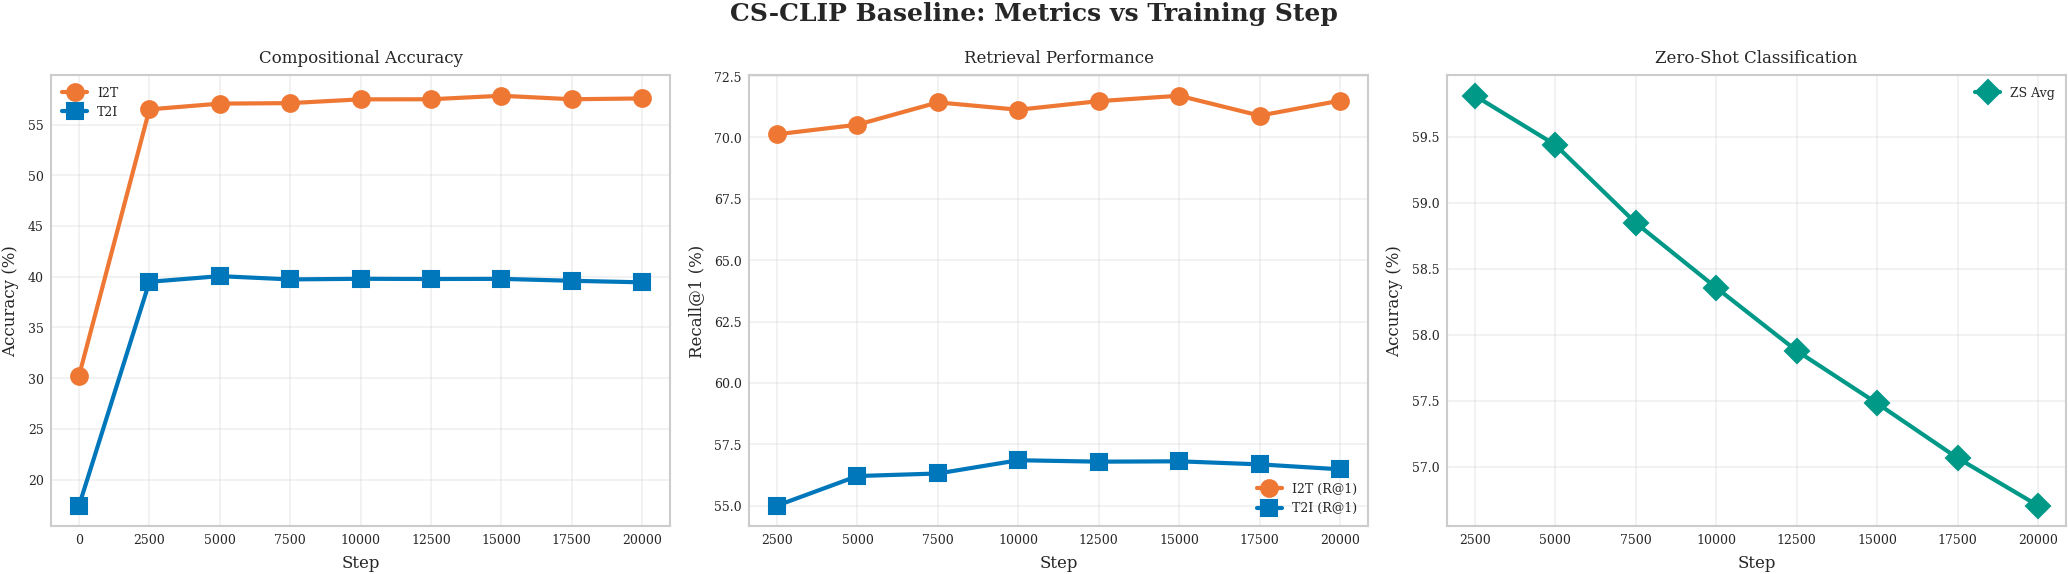


Figure saved as csclip_baseline_step_metrics.pdf and .png


In [24]:
# =============================================================================
# STEP-BY-STEP METRICS: Comp I2T/T2I, ZS, Retrieval for CS-CLIP Baseline
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Load the baseline CSV
baseline_csv = "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv"
df_raw = pd.read_csv(baseline_csv)

# Expand VisMin nested rows
df_raw = expand_vismin_nested_rows(df_raw)

# Apply dataset merge rules and metric mappings
if BENCHMARK_CONFIG:
    df_raw = apply_dataset_merge_rules(df_raw, BENCHMARK_CONFIG)
    df_raw = evalviz_apply_mappings(df_raw, BENCHMARK_CONFIG)

df_raw['value'] = pd.to_numeric(df_raw['value'], errors='coerce')

# Get unique steps
steps = sorted(df_raw['step'].dropna().unique())
print(f"Available steps: {steps}")

# Define retrieval and zero-shot datasets
RETRIEVAL_DATASETS = ['wds_mscoco_captions', 'wds_flickr30k', 'wds_flickr8k']
ZS_DATASETS = [
    'wds_vtab-caltech101', 'wds_sun397', 'wds_imagenet_sketch', 
    'wds_stanford_cars', 'wds_imagenet1k', 'wds_imagenetv2',
    'wds_objectnet', 'wds_fgvc_aircraft', 'wds_country211'
]

# Compute metrics per step
step_metrics = []

for step in steps:
    df_step = df_raw[df_raw['step'] == step]
    row = {'step': step}
    
    # --- Compositional I2T (text_contrastive_accuracy) ---
    comp_i2t_df = df_step[(df_step['metric'] == 'text_contrastive_accuracy') & 
                          (df_step['dataset'] != 'CLIPBench')]
    if len(comp_i2t_df) > 0:
        dataset_avg = comp_i2t_df.groupby('dataset')['value'].mean()
        row['Comp_I2T'] = dataset_avg.mean() * 100
    
    # --- Compositional T2I (image_contrastive_accuracy) ---
    comp_t2i_df = df_step[(df_step['metric'] == 'image_contrastive_accuracy') & 
                          (df_step['dataset'] != 'CLIPBench')]
    if len(comp_t2i_df) > 0:
        dataset_avg = comp_t2i_df.groupby('dataset')['value'].mean()
        row['Comp_T2I'] = dataset_avg.mean() * 100
    
    # --- CLIPBench Retrieval (I2T: text_retrieval_recall@1, T2I: image_retrieval_recall@1) ---
    clipbench = df_step[df_step['dataset'] == 'CLIPBench']
    
    # I2T Retrieval (text retrieval)
    i2t_retr = clipbench[(clipbench['metric'] == 'text_retrieval_recall@1') & 
                          (clipbench['subset'].isin(RETRIEVAL_DATASETS))]
    if len(i2t_retr) > 0:
        row['Retr_I2T'] = i2t_retr['value'].mean() * 100
    
    # T2I Retrieval (image retrieval)
    t2i_retr = clipbench[(clipbench['metric'] == 'image_retrieval_recall@1') & 
                          (clipbench['subset'].isin(RETRIEVAL_DATASETS))]
    if len(t2i_retr) > 0:
        row['Retr_T2I'] = t2i_retr['value'].mean() * 100
    
    # --- Zero-Shot Classification (acc1) ---
    zs = clipbench[(clipbench['metric'] == 'acc1') & 
                   (clipbench['subset'].isin(ZS_DATASETS))]
    if len(zs) > 0:
        row['ZS_Avg'] = zs['value'].mean() * 100
    
    step_metrics.append(row)

df_steps = pd.DataFrame(step_metrics)
print("\nMetrics per step:")
display(df_steps.round(2))

# =============================================================================
# PLOT: Step vs Metrics
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Define colors
colors = {
    'Comp_I2T': '#EE7733',  # Orange
    'Comp_T2I': '#0077BB',  # Blue
    'Retr_I2T': '#EE7733',
    'Retr_T2I': '#0077BB', 
    'ZS_Avg': '#009988',    # Teal
}

# Plot 1: Compositional I2T & T2I
ax1 = axes[0]
ax1.plot(df_steps['step'], df_steps['Comp_I2T'], 'o-', color=colors['Comp_I2T'], 
         label='I2T', linewidth=2, markersize=8)
ax1.plot(df_steps['step'], df_steps['Comp_T2I'], 's-', color=colors['Comp_T2I'], 
         label='T2I', linewidth=2, markersize=8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Compositional Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Retrieval I2T & T2I
ax2 = axes[1]
if 'Retr_I2T' in df_steps.columns:
    ax2.plot(df_steps['step'], df_steps['Retr_I2T'], 'o-', color=colors['Retr_I2T'], 
             label='I2T (R@1)', linewidth=2, markersize=8)
if 'Retr_T2I' in df_steps.columns:
    ax2.plot(df_steps['step'], df_steps['Retr_T2I'], 's-', color=colors['Retr_T2I'], 
             label='T2I (R@1)', linewidth=2, markersize=8)
ax2.set_xlabel('Step')
ax2.set_ylabel('Recall@1 (%)')
ax2.set_title('Retrieval Performance')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Zero-Shot Classification
ax3 = axes[2]
if 'ZS_Avg' in df_steps.columns:
    ax3.plot(df_steps['step'], df_steps['ZS_Avg'], 'D-', color=colors['ZS_Avg'], 
             label='ZS Avg', linewidth=2, markersize=8)
ax3.set_xlabel('Step')
ax3.set_ylabel('Accuracy (%)')
ax3.set_title('Zero-Shot Classification')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('CS-CLIP Baseline: Metrics vs Training Step', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/csclip_baseline_step_metrics.pdf', bbox_inches='tight', dpi=150)
plt.savefig('../figures/csclip_baseline_step_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nFigure saved as csclip_baseline_step_metrics.pdf and .png")